In [1]:
import os, pickle, re, unicodedata, itertools
from pathlib import Path
from dataclasses import asdict
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import hdbscan
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize

import itertools
from collections import Counter
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.cm as cm

def extract_researches_results(rot_dir: str | os.PathLike): 
    researches = []
    for papers in os.listdir(rot_dir):
        researches_results_path = os.path.join(rot_dir, papers)
        with open(researches_results_path, "rb") as file: 
            research = asdict(pickle.load(file))
            researches.append(research)
    return researches

def extract_papers(researches : list[dict]):            
    papers = []
    for results in researches:
        for paper in results["papers"].values():
            papers.append(paper)
    return papers

dir_acm_path = os.path.join("papers", "acm")
dir_ieee_path = os.path.join("papers", "ieee")
    
researches_acm = extract_papers(extract_researches_results(dir_acm_path))
researches_ieee = extract_papers(extract_researches_results(dir_ieee_path))

researches = researches_acm
researches.extend(researches_ieee)

df = pd.DataFrame(researches)
df_clean = df.drop_duplicates(subset="DOI", keep="first").reset_index(drop=True)

/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_36319/697060573.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("winter")  # winter vai do azul ao verde


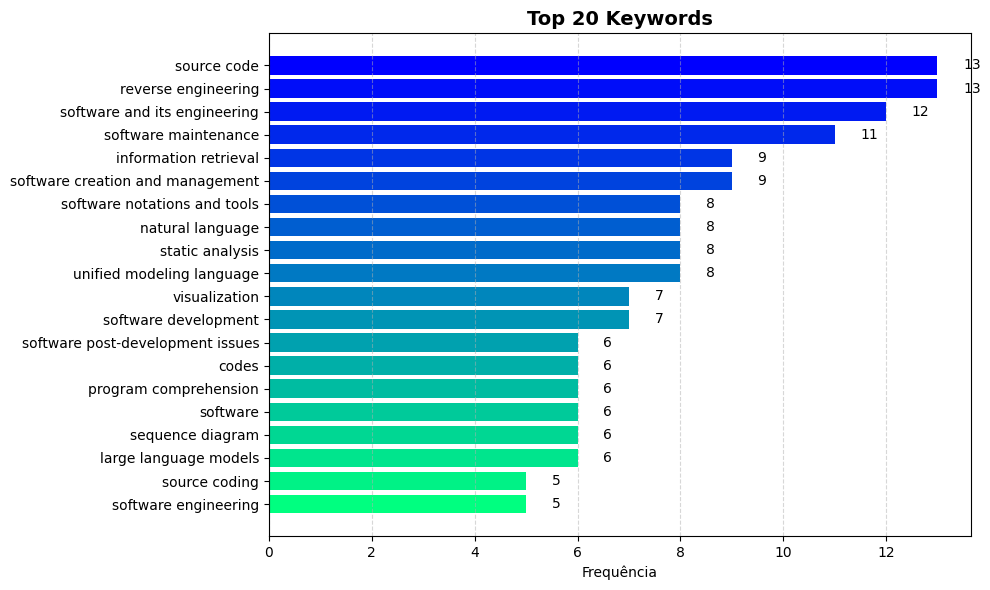

In [ ]:
import itertools
from collections import Counter
import matplotlib.pyplot as plt
import squarify  # treemap


# --- Flatten keywords ---
def normalize_keyword(word: str) -> str:
    nfkd = unicodedata.normalize("NFKD", word)
    return "".join([c for c in nfkd if not unicodedata.combining(c)]).lower()

valid_keywords = [k for k in df_clean["keywords"] if isinstance(k, list)]
flat_keywords = list(itertools.chain.from_iterable(valid_keywords))
flat_keywords = [normalize_keyword(k) for k in flat_keywords]


# --- Contagem ---
keyword_counts = Counter(flat_keywords)
top20 = keyword_counts.most_common(20)

# --- Gráfico de barras ---
labels, values = zip(*top20)

# cores no degradê azul → verde
cmap = cm.get_cmap("winter")  # winter vai do azul ao verde
colors = cmap(np.linspace(0, 1, len(values)))

plt.figure(figsize=(10, 6))
bars = plt.barh(labels[::-1], values[::-1], color=colors[::-1])  

# adicionar os valores no final de cada barra
for bar, value in zip(bars, values[::-1]):
    plt.text(
        bar.get_width() + 0.5,           # deslocamento para direita da barra
        bar.get_y() + bar.get_height()/2, 
        str(value),
        va="center",
        ha="left",
        fontsize=10,
        color="black"
    )

# estética geral
plt.xlabel("Frequência")
plt.title("Top 20 Keywords", fontsize=14, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
def _safe_load_pickle(path: Path):
    try:
        with open(path, "rb") as f:
            obj = pickle.load(f)
        return asdict(obj) if hasattr(obj, "__dataclass_fields__") else obj
    except Exception as e:
        print(f"[WARN] Falha ao ler {path}: {e}")
        return None

def load_researches_from_dir(root_dir: Path):
    researches = []
    for fname in os.listdir(root_dir):
        rec = _safe_load_pickle(root_dir / fname)
        if isinstance(rec, dict):
            researches.append(rec)
    return researches

def extract_papers(researches):
    papers = []
    for r in researches:
        if "papers" in r:
            papers.extend(r["papers"].values())
    return papers

# carregar
researches_acm = load_researches_from_dir(acm_dir)
researches_ieee = load_researches_from_dir(ieee_dir)
papers = extract_papers(researches_acm) + extract_papers(researches_ieee)

df = pd.DataFrame(papers).drop_duplicates(subset="DOI", keep="first").reset_index(drop=True)
df.head()


NameError: name 'acm_dir' is not defined

In [ ]:
valid_keywords = [k for k in df["keywords"] if isinstance(k, list)]
flat_keywords = list(itertools.chain.from_iterable(valid_keywords))
keyword_counts = Counter(flat_keywords)

df_kw = pd.DataFrame(keyword_counts.items(), columns=["keyword", "count"])
df_kw.head()


,keyword,count
0,Human-centered computing,3
1,Information systems,4
2,Information retrieval,4
3,Social and professional topics,3
4,Professional topics,3


In [ ]:
X = model.encode(df_kw["keyword"].tolist())
Xn = normalize(X)

clusterer = hdbscan.HDBSCAN(min_cluster_size=3, metric="euclidean")
df_kw["cluster"] = clusterer.fit_predict(Xn)

df_kw.sample(10)  # inspeciona 10 linhas aleatórias


/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,keyword,count,cluster
15,Software verification and validation,1,-1
259,Automatic Generation,1,16
354,Registration Process,1,-1
374,Color Sensor,1,-1
273,Collaboration,1,-1
409,Refactoring,1,-1
245,Current Scope,1,-1
459,Unified Modelling Language,1,19
408,Large language models (LLMs),1,17
47,Context specific languages,1,-1


In [ ]:
clusters = (
    df_kw.groupby("cluster")["keyword"]
         .apply(list)
         .to_dict()
)

clusters  # veja como ficaram agrupadas as palavras


{-1: ['Human-centered computing',
  'Information systems',
  'Social and professional topics',
  'Professional topics',
  'Management of computing and information systems',
  'Software creation and management',
  'Software post-development issues',
  'Software notations and tools',
  'Reusability',
  'Software product lines',
  'Software verification and validation',
  'Process validation',
  'Traceability',
  'Software defect analysis',
  'System description languages',
  'Applied computing',
  'Arts and humanities',
  'Computing methodologies',
  'Software evolution',
  'Software version control',
  'Security and privacy',
  'Systems security',
  'Operating systems security',
  'Trusted computing',
  'Context specific languages',
  'Domain specific languages',
  'Education',
  'Human computer interaction (HCI)',
  'Computing education programs',
  'Computer science education',
  'Software organization and properties',
  'Graph Neural Networks',
  'Training Set',
  'Gated Recurrent Un

In [ ]:
_punct_tbl = str.maketrans("", "", r"""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~""")

def _norm_token(s: str) -> str:
    s = unicodedata.normalize("NFKC", s).lower().strip()
    s = s.translate(_punct_tbl)
    s = re.sub(r"\s+", " ", s)
    return s

def _to_token_set(words):
    if not isinstance(words, (list, tuple, set)):
        return set()
    return {_norm_token(w) for w in words if isinstance(w, str) and w.strip()}

def label_topics(keywords, clusters_dict):
    keyset = _to_token_set(keywords)
    hits = []
    for cid, terms in clusters_dict.items():
        termset = _to_token_set(terms)
        if keyset & termset:
            hits.append(cid)
    return hits or ["Other"]

df["topic_ids"] = df["keywords"].apply(lambda ks: label_topics(ks, clusters))
df.head()


,title,date,abstract,DOI,source_url,authors,keywords,topic_ids
0,Supporting Readability by Comprehending the Hi...,24 February 2022,Exploring the source code of a software system...,10.1145/3511430.3511441,https://dl.acm.org/doi/10.1145/3511430.3511441,"[Avijit Bhattacharjee, Banani Roy, Kevin Schne...","[Human-centered computing, Information systems...","[-1, 5, 15, 20]"
1,Test2Feature: feature-based test traceability ...,12 September 2022,To ensure the quality of Highly Configurable S...,10.1145/3503229.3547031,https://dl.acm.org/doi/10.1145/3503229.3547031,"[Willian D. F. Mendonça, Silvia R. Vergilio, G...","[Software and its engineering, Software creati...","[-1, 7, 15, 20]"
2,Executable Multi-Layered Software Models,25 July 2024,This paper introduces a novel software visuali...,10.1145/3643660.3643938,https://dl.acm.org/doi/10.1145/3643660.3643938,"[Lukas Radosky, Ivan Polasek]","[Software and its engineering, Software creati...","[-1, 10, 19, 20]"
3,Re-Engineering Microservices into Web-Based So...,01 September 2025,None,10.1145/3748269.3748490,https://dl.acm.org/doi/10.1145/3748269.3748490,"[Rifqi Farel Muhammad, Bonaventura Galang Kris...","[Software and its engineering, Software creati...","[-1, 19, 20]"
4,Enhancing Model-Driven Reverse Engineering Usi...,23 May 2024,Organizations often rely on large applications...,10.1145/3639478.3639797,https://dl.acm.org/doi/10.1145/3639478.3639797,[Hanan Abdulwahab Siala],None,[Other]


In [ ]:
tp = df.explode("topic_ids", ignore_index=True)
tp = tp[tp["topic_ids"] != "Other"]

topic_counts = (
    tp.groupby("topic_ids")
      .size()
      .rename("n")
      .reset_index()
)

topic_counts = topic_counts.sort_values("n", ascending=True)
topic_counts


,topic_ids,n
10,9,1
9,8,2
11,10,2
19,18,2
18,17,3
22,21,3
5,4,3
7,6,4
23,22,4
1,0,4


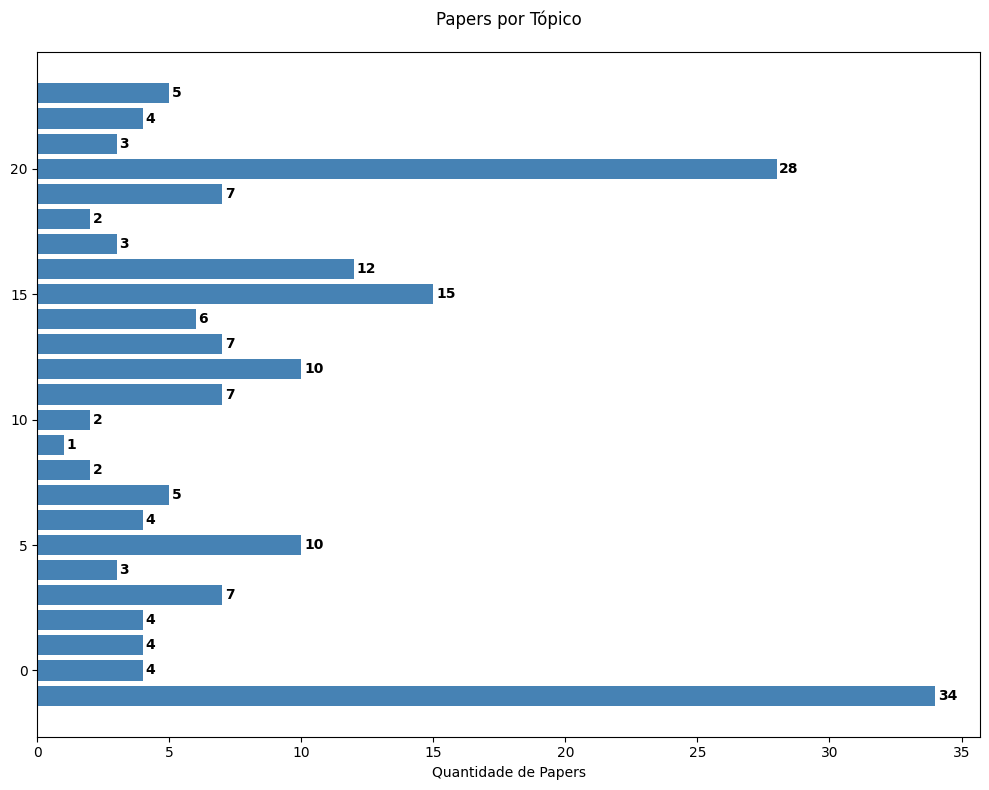

In [ ]:
plt.figure(figsize=(10, 8))
ax = plt.gca()

bars = ax.barh(topic_counts["topic_ids"], topic_counts["n"], color="steelblue")
plt.title("Papers por Tópico", pad=20)
plt.xlabel("Quantidade de Papers")

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.1, bar.get_y() + bar.get_height()/2,
            f"{width:.0f}", va="center", ha="left", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()
